In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

In [3]:
df_test.head(3)

,selling_price,km_driven,transmission,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,...,brand_Nissan.1,brand_Opel.1,brand_Peugeot.1,brand_Renault.1,brand_Skoda.1,brand_Tata.1,brand_Toyota.1,brand_Volkswagen.1,brand_Volvo.1,car_age
0,120000,120000,0,1,17.8,1086.0,63.0,5.0,0,0,...,0,0,0,0,0,0,0,0,0,19
1,130000,120000,0,1,19.3,1248.0,82.0,5.0,1,0,...,0,0,0,0,0,1,0,0,0,13
2,626000,80000,0,1,12.8,2494.0,102.0,7.0,1,0,...,0,0,0,0,0,0,1,0,0,19


In [4]:
X_train = df_train.drop(columns = ['selling_price'])
Y_train = df_train['selling_price']
X_test = df_test.drop(columns= ['selling_price'])
Y_test = df_test['selling_price']

In [5]:
X_train.shape

(5634, 75)

In [6]:
X_train_mean = X_train.mean()
X_train_std = X_train.std()
X_train_std[X_train_std == 0] = 1.0
X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

In [7]:
X_train_scaled

,km_driven,transmission,owner,mileage,engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,...,brand_Nissan.1,brand_Opel.1,brand_Peugeot.1,brand_Renault.1,brand_Skoda.1,brand_Tata.1,brand_Toyota.1,brand_Volkswagen.1,brand_Volvo.1,car_age
0,-0.733255,-0.296022,-0.654129,0.015873,0.337911,1.665731,-0.458985,0.895956,-0.066756,-0.874903,...,-0.105476,0.0,-0.013323,-0.182692,-0.120006,-0.32087,-0.233777,-0.163091,-0.013323,-0.850951
1,-0.098277,-0.296022,0.726156,0.294483,-0.426310,0.062189,1.639125,0.895956,-0.066756,-0.874903,...,-0.105476,0.0,-0.013323,-0.182692,-0.120006,-0.32087,-0.233777,-0.163091,-0.013323,-0.326759
2,-0.671805,-0.296022,-0.654129,1.244289,-0.426310,0.051053,1.639125,0.895956,-0.066756,-0.874903,...,-0.105476,0.0,-0.013323,-0.182692,-0.120006,-0.32087,-0.233777,-0.163091,-0.013323,-0.850951
3,0.966846,3.377524,2.106442,-1.979986,1.703900,1.400187,2.688180,0.895956,-0.066756,-0.874903,...,-0.105476,0.0,-0.013323,-0.182692,-0.120006,-0.32087,-0.233777,-0.163091,-0.013323,0.459528
4,-0.057311,-0.296022,-0.654129,-0.179153,-0.543003,-0.227340,-0.458985,-1.115928,-0.066756,1.142781,...,-0.105476,0.0,-0.013323,-0.182692,-0.120006,-0.32087,-0.233777,-0.163091,-0.013323,-0.326759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,1.212643,-0.296022,0.726156,0.783317,0.145712,0.108445,-0.458985,0.895956,-0.066756,-0.874903,...,-0.105476,0.0,-0.013323,-0.182692,-0.120006,-0.32087,-0.233777,-0.163091,-0.013323,-0.064663
5630,-0.057311,-0.296022,0.726156,-0.356451,-0.426310,-0.578543,1.639125,0.895956,-0.066756,-0.874903,...,-0.105476,0.0,-0.013323,-0.182692,-0.120006,-0.32087,-0.233777,-0.163091,-0.013323,0.197433
5631,0.147520,-0.296022,-0.654129,0.590823,-0.545291,-1.096782,-0.458985,-1.115928,-0.066756,-0.874903,...,-0.105476,0.0,-0.013323,-0.182692,-0.120006,-0.32087,-0.233777,-0.163091,-0.013323,-0.588855
5632,0.352351,-0.296022,2.106442,1.568490,0.145712,0.483632,-0.458985,0.895956,-0.066756,-0.874903,...,-0.105476,0.0,-0.013323,-0.182692,-0.120006,-0.32087,-0.233777,-0.163091,-0.013323,0.197433


In [8]:
X_train_arr = np.asarray(X_train_scaled)
X_test_arr = np.asarray(X_test_scaled)

X_b_train = np.c_[np.ones(X_train_arr.shape[0]), X_train_arr]
X_b_test = np.c_[np.ones(X_test_arr.shape[0]), X_test_arr]

w = np.linalg.pinv(X_b_train.T @ X_b_train) @ X_b_train.T @ Y_train

In [9]:
w

array([ 4.74208177e+05, -3.32538841e+04,  1.40224117e+04, -1.47184571e+04,
       -1.00948217e+04,  1.82016063e+04,  9.16705768e+04,  1.63071649e+04,
        8.09356260e+04,  7.77483334e+03,  2.24356569e+04, -2.54685129e+03,
       -4.98683435e+03,  6.65875509e-09,  2.46272070e+03,  4.14419004e+03,
       -1.45968820e+04,  2.17086170e+03, -8.21992425e+03, -4.96328708e+03,
        5.61137431e+01, -7.09484262e+03,  1.21712929e+03, -5.82414996e+03,
        1.80409002e+03,  8.68547136e-09,  1.02290372e-09, -1.76202985e+03,
        2.44166010e-09, -1.53896590e-09, -3.88632871e-09, -8.94321710e+03,
       -3.04878031e+02,  2.00328942e+03,  3.04260653e+03, -3.19888588e+03,
        6.00549417e-13,  1.48743534e+03, -6.10429967e+03, -4.26656142e+03,
       -2.46863327e+04,  1.03740417e+04, -7.84895593e+03,  2.49096065e+03,
        0.00000000e+00,  2.46272070e+03,  4.14419004e+03, -1.45968820e+04,
        2.17086170e+03, -8.21992425e+03, -4.96328708e+03,  5.61137430e+01,
       -7.09484262e+03,  

In [10]:
Y_pred = X_b_test @ w

In [12]:
SS_res = np.sum((Y_pred - Y_test) ** 2)
SS_tot = np.sum((Y_test - np.mean(Y_test)) ** 2)
R_squared = 1 - SS_res / SS_tot

MAE = np.mean(np.abs(Y_pred - Y_test))

MSE = np.mean((Y_pred - Y_test) ** 2)

RMSE = np.sqrt(MSE)

MAE = np.mean(np.abs(Y_pred - Y_test))

print(f"MSE :  {MSE}")
print(f"RMSE : {RMSE}")
print(f"MAE :  {MAE}")
print(f"R^2 : {R_squared}")

MSE :  15044219098.681528
RMSE : 122654.87800606027
MAE :  92174.15627855966
R^2 : 0.7643800639383925


In [13]:
real_price = Y_test.iloc[10]
predicted_price = Y_pred[10]

print(f"--- Real Car Inspection (Row 0) ---")
print(f"Actual Market Price:    {real_price:,.2f}")
print(f"Model's Guessed Price:  {predicted_price:,.2f}")

difference = predicted_price - real_price
print(f"Difference:             {difference:,.2f}")

--- Real Car Inspection (Row 0) ---
Actual Market Price:    300,000.00
Model's Guessed Price:  337,502.48
Difference:             37,502.48


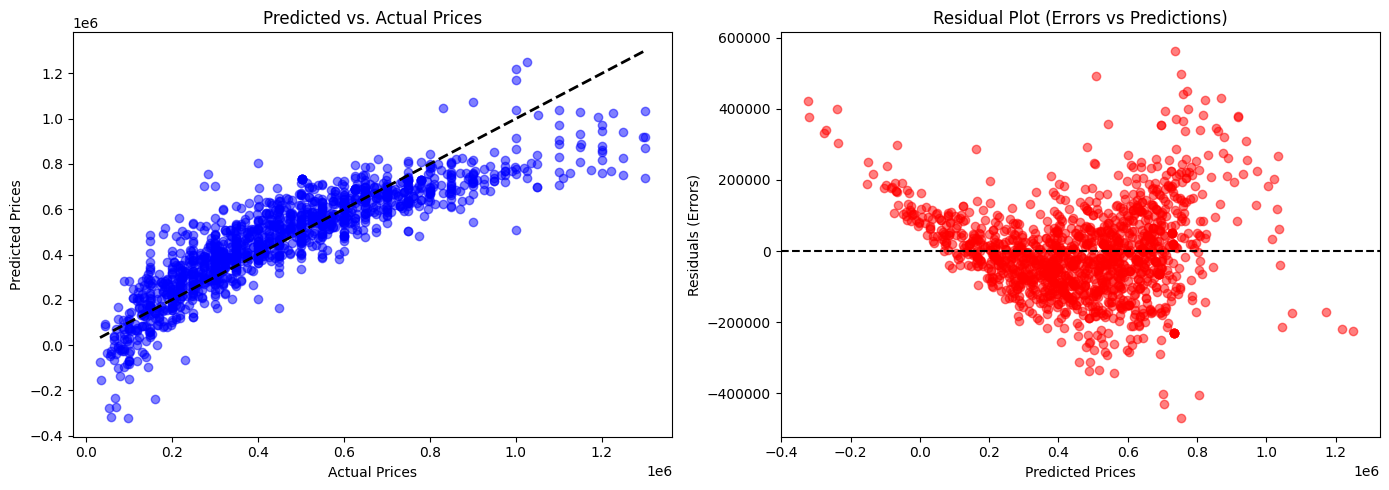

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(Y_test, Y_pred, color='blue', alpha=0.5)
ax1.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
ax1.set_xlabel('Actual Prices')
ax1.set_ylabel('Predicted Prices')
ax1.set_title('Predicted vs. Actual Prices')

residuals = Y_test - Y_pred
ax2.scatter(Y_pred, residuals, color='red', alpha=0.5)
ax2.axhline(y=0, color='black', linestyle='--')
ax2.set_xlabel('Predicted Prices')
ax2.set_ylabel('Residuals (Errors)')
ax2.set_title('Residual Plot (Errors vs Predictions)')

plt.tight_layout()
plt.show()